In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import plotly.graph_objects as go

In [2]:
fo = "../data/001_raw/ERA5_Oaxaca_2023.nc"
fm = "../data/001_Raw/ERA5_Morelos_2023.nc"
oax = xr.open_dataset(fo)
mor = xr.open_dataset(fm)
#oax
#mor

In [3]:
#list(oax)
def extraer_datos_oaxaca(variable = "t2m"):
    
    return oax[variable]

extraer_datos_oaxaca("ssrd")

<xarray.DataArray 'ssrd' (time: 8760, latitude: 12, longitude: 19)> Size: 16MB
[1997280 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * latitude   (latitude) float32 48B 18.5 18.25 18.0 17.75 ... 16.25 16.0 15.75
  * longitude  (longitude) float32 76B -98.5 -98.25 -98.0 ... -94.5 -94.25 -94.0
Attributes:
    units:          J m**-2
    long_name:      Surface short-wave (solar) radiation downwards
    standard_name:  surface_downwelling_shortwave_flux_in_air

In [4]:
def extraer_datos_morelos(variable = "t2m"):
    
    return mor[variable]

extraer_datos_morelos("ssrd")

<xarray.DataArray 'ssrd' (time: 8760, latitude: 3, longitude: 4)> Size: 841kB
[105120 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * latitude   (latitude) float32 12B 19.0 18.75 18.5
  * longitude  (longitude) float32 16B -99.5 -99.25 -99.0 -98.75
Attributes:
    units:          J m**-2
    long_name:      Surface short-wave (solar) radiation downwards
    standard_name:  surface_downwelling_shortwave_flux_in_air

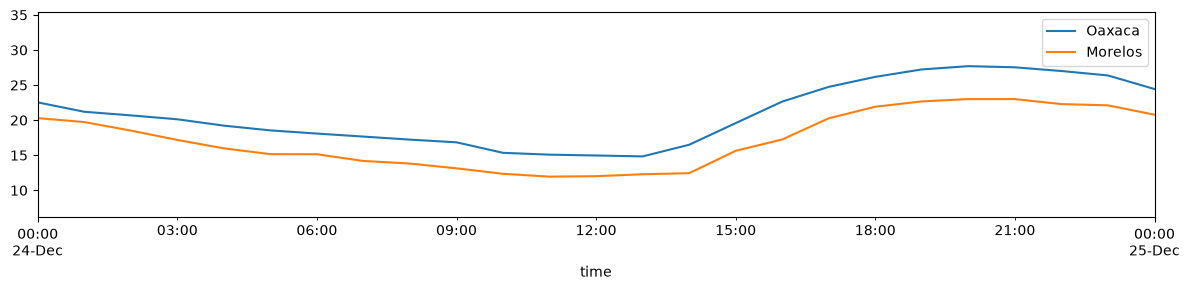

In [5]:
df_oax = oax.to_dataframe()
df_mor = mor.to_dataframe()

df_oax["t2m_celsius"] = df_oax["t2m"] - 273.15
df_mor["t2m_celsius"] = df_mor["t2m"] - 273.15


t2m_prom_oax = df_oax.groupby(level ="time")["t2m_celsius"].mean()
t2m_prom_mor = df_mor.groupby(level ="time")["t2m_celsius"].mean()

f1 = pd.to_datetime("2023-12-24")
f2 = f1 + pd.Timedelta("1D")

fig, ax = plt.subplots(figsize=(12, 3))
t2m_prom_oax.plot(label = "Oaxaca")
t2m_prom_mor.plot(label = "Morelos")
ax.set_xlim(f1,f2)

ax.legend()
plt.tight_layout()
plt.show()

#df_oax


In [6]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=t2m_prom_oax.index, 
    y=t2m_prom_oax.values,
    mode="lines",
    name="Oaxaca",
    
))

fig.add_trace(go.Scatter(
    x=t2m_prom_mor.index, 
    y=t2m_prom_mor.values,
    mode="lines",
    name="Morelos",
))

fig.update_layout(
    xaxis_title="fecha",
    yaxis_title="temperatura",
    xaxis=dict(range=[f1, f2]), 
    width=1200,
    height=400
)

fig.show()

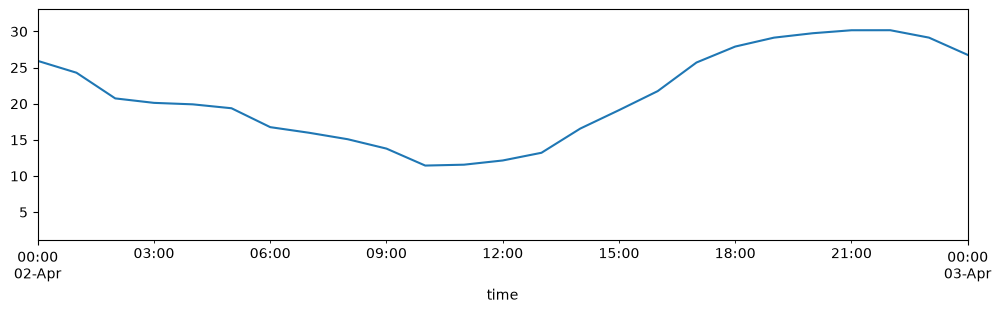

In [7]:
lat_casa =17.815060636747624
lon_casa = -97.79160933614862
casa = oax.sel(
    latitude= lat_casa,
    longitude= lon_casa,
    method = "nearest"
)

df_casa = casa.to_dataframe()
df_casa["t2m_celsius"] = df_casa["t2m"] - 273.15

f1 = pd.to_datetime("2023-04-02")
f2 = f1 + pd.Timedelta("1D")

fig, ax = plt.subplots(figsize=(12, 3))
df_casa["t2m_celsius"].plot()
ax.set_xlim(f1, f2)

plt.show()

In [8]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x = df_casa.index,
    y = df_casa["t2m_celsius"],
    mode = "lines",
    
))

fig.update_layout(
    xaxis_title= "Fecha",
    yaxis_title = "Temperatura",
    xaxis = dict(range=[f1,f2]),
    width=1200,
    height=400
)

fig.show()